In [ ]:
!pip install raster

In [ ]:
!pip install laspy numpy pandas

In [ ]:
!pip install pylas lazrs

In [ ]:
!pip install open3d

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
# Mount and connect to the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

import laspy
import numpy as np
import pandas as pd

# If uploaded manually, the file will be in /content/
las_file_path = "/content/drive/MyDrive/Artis_AHN3.las"

# Open the LAS file
las = laspy.read(las_file_path)

# Extract point cloud data
points = np.vstack((las.x, las.y, las.z)).T  # XYZ coordinates
intensity = las.intensity  # Intensity values
classification = las.classification  # Classification codes

# Convert to Pandas DataFrame for analysis
df = pd.DataFrame({
    'X': points[:, 0],
    'Y': points[:, 1],
    'Z': points[:, 2],
    'Intensity': intensity,
    'Classification': classification,
    'NumberOfReturns': las.number_of_returns,
    'ReturnNumber': las.return_number,
    'GPS_time': las.gps_time,
    'Scan_angle_rank': las.scan_angle_rank,
    'UserData': las.user_data
})


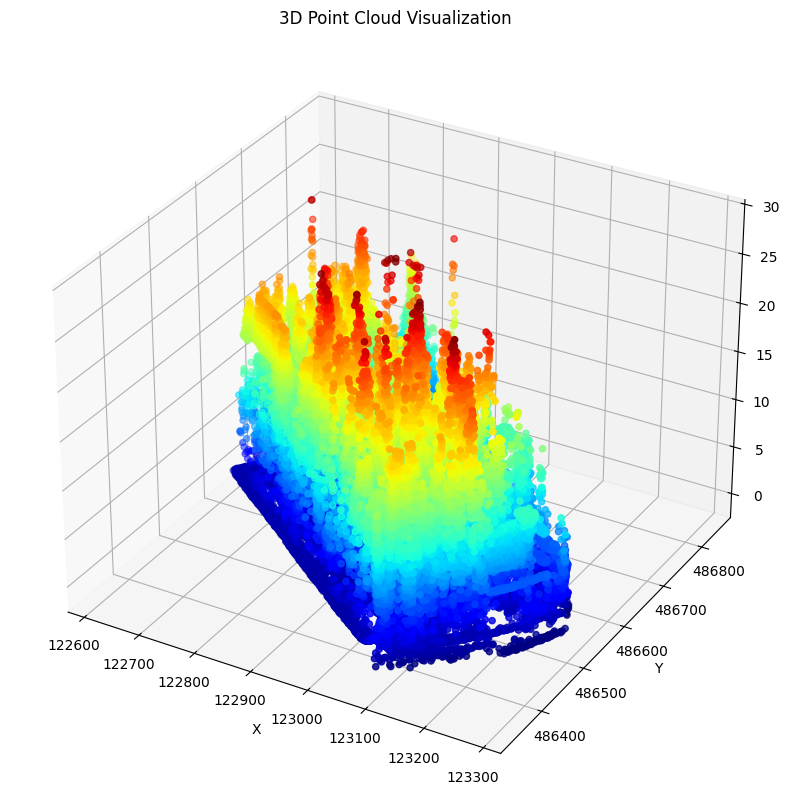

In [7]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['X'][::50], df['Y'][::50], df['Z'][::50], c=df['Z'][::50], cmap='jet')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D Point Cloud Visualization')
plt.show()


In [ ]:
import open3d as o3d

points = np.vstack((las.x, las.y, las.z)).T  # XYZ coordinates
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

o3d.visualization.draw_geometries([pcd])

# Not supported in Colab but on Desktop